# Automated Trading System - using LSTM Model

In [406]:
import pandas as pd 
import warnings
warnings.filterwarnings('ignore')


In [407]:
#load the dataset
cp= pd.read_csv('btcusd.csv')

In [408]:
#display the first 5 rows in the dataset
cp.head()

,timestamp,open,high,low,close,volume
0,2024-10-22,67346.15,67373.06,67060.30,67073.08,120.458109
1,2024-10-21,69014.87,69498.00,66802.00,67346.15,10226.593467
2,2024-10-20,68363.73,69380.00,68083.18,69014.86,2632.892149
3,2024-10-19,68426.11,68689.29,68005.83,68363.73,1868.869588
4,2024-10-18,67399.86,69000.62,67149.24,68426.11,11802.744419


In [409]:
#view the number of rows and columns
cp.shape

(350, 6)

In [410]:
#view the datatypes of each features in the dataset
cp.info()
cp.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  350 non-null    object 
 1   open       350 non-null    float64
 2   high       350 non-null    float64
 3   low        350 non-null    float64
 4   close      350 non-null    float64
 5   volume     350 non-null    float64
dtypes: float64(5), object(1)
memory usage: 16.5+ KB


Index(['timestamp', 'open', 'high', 'low', 'close', 'volume'], dtype='object')

In [411]:
#The timestamp feature has object has datatype, we want to convert it to datetime 
import datetime as dt
from datetime import datetime
cp['timestamp'] = pd.to_datetime(cp['timestamp'])
cp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  350 non-null    datetime64[ns]
 1   open       350 non-null    float64       
 2   high       350 non-null    float64       
 3   low        350 non-null    float64       
 4   close      350 non-null    float64       
 5   volume     350 non-null    float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 16.5 KB


In [412]:
#lets rename the timestamp column to date

cp.rename(columns={'timestamp': 'date'}, inplace=True)
cp.head()

,date,open,high,low,close,volume
0,2024-10-22,67346.15,67373.06,67060.30,67073.08,120.458109
1,2024-10-21,69014.87,69498.00,66802.00,67346.15,10226.593467
2,2024-10-20,68363.73,69380.00,68083.18,69014.86,2632.892149
3,2024-10-19,68426.11,68689.29,68005.83,68363.73,1868.869588
4,2024-10-18,67399.86,69000.62,67149.24,68426.11,11802.744419


### Adding technical Indicators (RSI & SMI)

In [413]:
#Import finta
from finta import TA

In [414]:
ohlcv=cp[['open','high','low','close','volume']]
ohlcv.head()

,open,high,low,close,volume
0,67346.15,67373.06,67060.30,67073.08,120.458109
1,69014.87,69498.00,66802.00,67346.15,10226.593467
2,68363.73,69380.00,68083.18,69014.86,2632.892149
3,68426.11,68689.29,68005.83,68363.73,1868.869588
4,67399.86,69000.62,67149.24,68426.11,11802.744419


In [415]:
cp['SMA']=TA.SMA(ohlcv, 42)
cp['RSI']=TA.RSI(ohlcv)
cp.head()

,date,open,high,low,close,volume,SMA,RSI
0,2024-10-22,67346.15,67373.06,67060.30,67073.08,120.458109,NaN,NaN
1,2024-10-21,69014.87,69498.00,66802.00,67346.15,10226.593467,NaN,100.000000
2,2024-10-20,68363.73,69380.00,68083.18,69014.86,2632.892149,NaN,100.000000
3,2024-10-19,68426.11,68689.29,68005.83,68363.73,1868.869588,NaN,73.271619
4,2024-10-18,67399.86,69000.62,67149.24,68426.11,11802.744419,NaN,73.988907


In [416]:
cp.tail()

,date,open,high,low,close,volume,SMA,RSI
345,2023-11-12,37139.94,37247.00,36740.90,37086.03,3317.502786,40065.868333,44.410541
346,2023-11-11,37324.84,37424.03,36701.50,37139.12,5344.453828,39909.029524,44.682801
347,2023-11-10,36704.01,37548.80,36334.46,37324.83,15183.168535,39749.770000,45.684922
348,2023-11-09,35639.13,37999.00,35555.16,36706.59,29045.851956,39579.085952,42.898731
349,2023-11-08,35416.63,36113.59,35103.14,35639.13,12253.158085,39387.761190,38.529451


In [417]:
# Fill missing values in the SMA & RSI with the median
cp['SMA'].fillna(cp['SMA'].median(), inplace=True)
cp['RSI'].fillna(cp['RSI'].median(), inplace=True)
cp

,date,open,high,low,close,volume,SMA,RSI
0,2024-10-22,67346.15,67373.06,67060.30,67073.08,120.458109,61904.077619,47.078523
1,2024-10-21,69014.87,69498.00,66802.00,67346.15,10226.593467,61904.077619,100.000000
2,2024-10-20,68363.73,69380.00,68083.18,69014.86,2632.892149,61904.077619,100.000000
3,2024-10-19,68426.11,68689.29,68005.83,68363.73,1868.869588,61904.077619,73.271619
4,2024-10-18,67399.86,69000.62,67149.24,68426.11,11802.744419,61904.077619,73.988907
...,...,...,...,...,...,...,...,...
345,2023-11-12,37139.94,37247.00,36740.90,37086.03,3317.502786,40065.868333,44.410541
346,2023-11-11,37324.84,37424.03,36701.50,37139.12,5344.453828,39909.029524,44.682801
347,2023-11-10,36704.01,37548.80,36334.46,37324.83,15183.168535,39749.770000,45.684922
348,2023-11-09,35639.13,37999.00,35555.16,36706.59,29045.851956,39579.085952,42.898731


In [418]:
import matplotlib.pyplot as plt

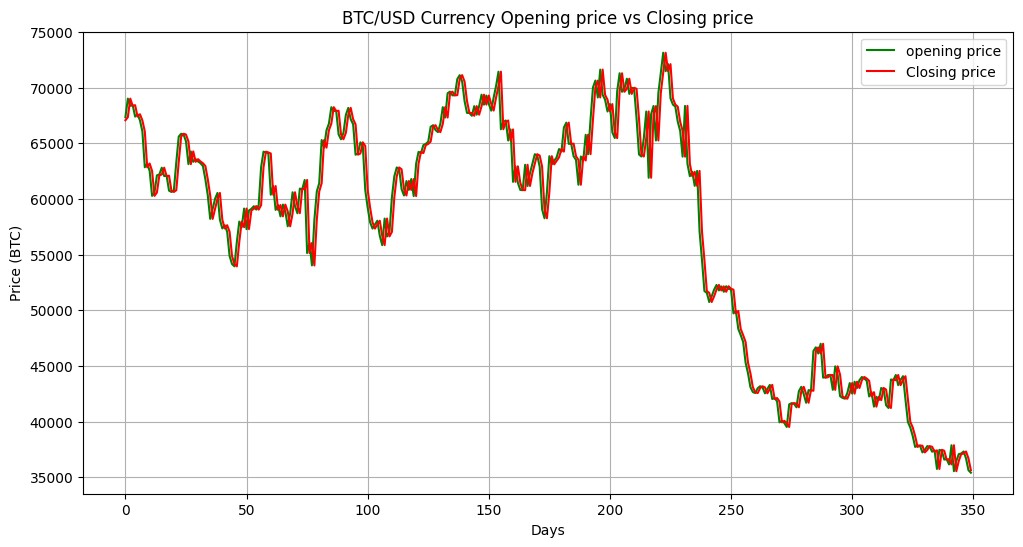

In [419]:
#lets visualize the closing price for Btc
plt.figure(figsize=(12, 6))
plt.plot(cp['open'],'g', label='opening price')
plt.plot(cp['close'],'r',label='Closing price')
plt.title("BTC/USD Currency Opening price vs Closing price")
plt.xlabel("Days")
plt.ylabel("Price (BTC)")
plt.grid(True)
plt.legend()
plt.show() 

In [420]:
cp.corr()

,date,open,high,low,close,volume,SMA,RSI
date,1.000000,0.694162,0.689380,0.702625,0.691908,-0.268540,0.631496,0.231300
open,0.694162,1.000000,0.994598,0.992652,0.988857,-0.046452,0.870821,0.548233
high,0.689380,0.994598,1.000000,0.991204,0.995993,-0.007687,0.878047,0.550754
low,0.702625,0.992652,0.991204,1.000000,0.994231,-0.116268,0.871360,0.556634
close,0.691908,0.988857,0.995993,0.994231,1.000000,-0.051639,0.878270,0.558233
volume,-0.268540,-0.046452,-0.007687,-0.116268,-0.051639,1.000000,-0.022674,-0.018235
SMA,0.631496,0.870821,0.878047,0.871360,0.878270,-0.022674,1.000000,0.187959
RSI,0.231300,0.548233,0.550754,0.556634,0.558233,-0.018235,0.187959,1.000000


<Axes: >

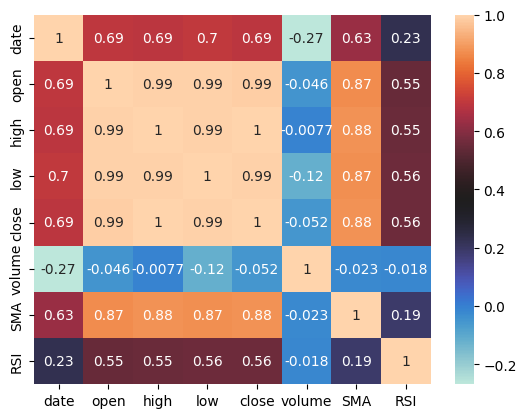

In [421]:
import seaborn as sns
sns.heatmap(cp.corr(), annot=True, cmap='icefire')

In [422]:
cp

,date,open,high,low,close,volume,SMA,RSI
0,2024-10-22,67346.15,67373.06,67060.30,67073.08,120.458109,61904.077619,47.078523
1,2024-10-21,69014.87,69498.00,66802.00,67346.15,10226.593467,61904.077619,100.000000
2,2024-10-20,68363.73,69380.00,68083.18,69014.86,2632.892149,61904.077619,100.000000
3,2024-10-19,68426.11,68689.29,68005.83,68363.73,1868.869588,61904.077619,73.271619
4,2024-10-18,67399.86,69000.62,67149.24,68426.11,11802.744419,61904.077619,73.988907
...,...,...,...,...,...,...,...,...
345,2023-11-12,37139.94,37247.00,36740.90,37086.03,3317.502786,40065.868333,44.410541
346,2023-11-11,37324.84,37424.03,36701.50,37139.12,5344.453828,39909.029524,44.682801
347,2023-11-10,36704.01,37548.80,36334.46,37324.83,15183.168535,39749.770000,45.684922
348,2023-11-09,35639.13,37999.00,35555.16,36706.59,29045.851956,39579.085952,42.898731


# Sentiment Analysis

### Collecting Btc news from NewsApi

In [423]:
from newsapi import NewsApiClient

In [424]:
newsapi = NewsApiClient(api_key='c247aced72954b3e909d99b0c0bab8b6')

In [425]:
news_data = newsapi.get_everything(q='btc', from_param='2023-18-11', to='2024-22-10',language='en', sort_by='relevancy')

In [426]:
# Extract headlines
headlines = [article['title'] for article in news_data['articles']]


### Using Vadersentiment to analyize sentiment

In [427]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [428]:
# Initialize the sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Analyze the sentiment of each headline
sentiments = [analyzer.polarity_scores(headline)['compound'] for headline in headlines]


In [429]:
# Convert into a DataFrame
import pandas as pd
news_sentiment_df = pd.DataFrame({
    'headline': headlines,
    'sentiment': sentiments
})


In [430]:
news_sentiment_df.head()

,headline,sentiment
0,"MicroStrategy Buys 1,070 BTC, Plans to Raise U...",0.0000
1,"Large Bitcoin Holders Accumulate 34,000 BTC Fo...",0.0000
2,Crypto surge: Key players reveal their strategies,0.0000
3,MicroStrategy Signals 11th Bitcoin Purchase as...,0.2500
4,"The Random Show — 2025 Predictions (AI, Aliens...",0.5859


In [431]:
#since news api can not fetch news beyond 2023-18-11 , we have tv remove the last 10 rows to match with the news api time range
cp.drop(cp.tail(10).index, inplace=True)

In [432]:
#datasets end at 2023-18-11
cp.tail()

,date,open,high,low,close,volume,SMA,RSI
335,2023-11-22,35755.33,37875.00,35633.00,37424.31,17606.972395,41586.480238,33.255610
336,2023-11-21,37472.76,37675.77,35744.90,35751.89,20837.739343,41366.934762,27.397369
337,2023-11-20,37389.06,37784.07,36720.00,37475.64,14114.010399,41206.336190,39.271651
338,2023-11-19,36596.14,37546.62,36404.52,37391.19,4366.448923,41089.744048,38.935672
339,2023-11-18,36631.56,36857.15,36205.89,36594.89,3468.398214,40957.693095,35.823501


In [433]:
#datasets starts at 24-10-22
cp.head()

,date,open,high,low,close,volume,SMA,RSI
0,2024-10-22,67346.15,67373.06,67060.30,67073.08,120.458109,61904.077619,47.078523
1,2024-10-21,69014.87,69498.00,66802.00,67346.15,10226.593467,61904.077619,100.000000
2,2024-10-20,68363.73,69380.00,68083.18,69014.86,2632.892149,61904.077619,100.000000
3,2024-10-19,68426.11,68689.29,68005.83,68363.73,1868.869588,61904.077619,73.271619
4,2024-10-18,67399.86,69000.62,67149.24,68426.11,11802.744419,61904.077619,73.988907


### Merging sentiment score and historical data based on date column

In [434]:

news_sentiment_df['date'] =(cp['date'])


In [435]:
# Merge the price data with the sentiment data based on date
combined_df = pd.merge(cp, news_sentiment_df, on='date', how='left')

# Fill missing sentiment data with neutral (0) sentiment
combined_df['sentiment'].fillna(0, inplace=True)

In [436]:
combined_df.head()

,date,open,high,low,close,volume,SMA,RSI,headline,sentiment
0,2024-10-22,67346.15,67373.06,67060.30,67073.08,120.458109,61904.077619,47.078523,"MicroStrategy Buys 1,070 BTC, Plans to Raise U...",0.0000
1,2024-10-21,69014.87,69498.00,66802.00,67346.15,10226.593467,61904.077619,100.000000,"Large Bitcoin Holders Accumulate 34,000 BTC Fo...",0.0000
2,2024-10-20,68363.73,69380.00,68083.18,69014.86,2632.892149,61904.077619,100.000000,Crypto surge: Key players reveal their strategies,0.0000
3,2024-10-19,68426.11,68689.29,68005.83,68363.73,1868.869588,61904.077619,73.271619,MicroStrategy Signals 11th Bitcoin Purchase as...,0.2500
4,2024-10-18,67399.86,69000.62,67149.24,68426.11,11802.744419,61904.077619,73.988907,"The Random Show — 2025 Predictions (AI, Aliens...",0.5859


In [437]:
combined_df.shape

(340, 10)

In [438]:
#since we are using LSTM model to predict btc price based on timeseries (date), we set the index of the datset to date column
combined_df.set_index('date', inplace=True)

In [439]:
combined_df

,open,high,low,close,volume,SMA,RSI,headline,sentiment
date,,,,,,,,,
2024-10-22,67346.15,67373.06,67060.30,67073.08,120.458109,61904.077619,47.078523,"MicroStrategy Buys 1,070 BTC, Plans to Raise U...",0.0000
2024-10-21,69014.87,69498.00,66802.00,67346.15,10226.593467,61904.077619,100.000000,"Large Bitcoin Holders Accumulate 34,000 BTC Fo...",0.0000
2024-10-20,68363.73,69380.00,68083.18,69014.86,2632.892149,61904.077619,100.000000,Crypto surge: Key players reveal their strategies,0.0000
2024-10-19,68426.11,68689.29,68005.83,68363.73,1868.869588,61904.077619,73.271619,MicroStrategy Signals 11th Bitcoin Purchase as...,0.2500
2024-10-18,67399.86,69000.62,67149.24,68426.11,11802.744419,61904.077619,73.988907,"The Random Show — 2025 Predictions (AI, Aliens...",0.5859
...,...,...,...,...,...,...,...,...,...
2023-11-22,35755.33,37875.00,35633.00,37424.31,17606.972395,41586.480238,33.255610,NaN,0.0000
2023-11-21,37472.76,37675.77,35744.90,35751.89,20837.739343,41366.934762,27.397369,NaN,0.0000
2023-11-20,37389.06,37784.07,36720.00,37475.64,14114.010399,41206.336190,39.271651,NaN,0.0000


### Feature Selection

In [440]:
#Extracting & rearranging the features to scale
features = ['close','open','high','low','volume','SMA','RSI','sentiment']

In [441]:
final=combined_df[features]

In [442]:
final

,close,open,high,low,volume,SMA,RSI,sentiment
date,,,,,,,,
2024-10-22,67073.08,67346.15,67373.06,67060.30,120.458109,61904.077619,47.078523,0.0000
2024-10-21,67346.15,69014.87,69498.00,66802.00,10226.593467,61904.077619,100.000000,0.0000
2024-10-20,69014.86,68363.73,69380.00,68083.18,2632.892149,61904.077619,100.000000,0.0000
2024-10-19,68363.73,68426.11,68689.29,68005.83,1868.869588,61904.077619,73.271619,0.2500
2024-10-18,68426.11,67399.86,69000.62,67149.24,11802.744419,61904.077619,73.988907,0.5859
...,...,...,...,...,...,...,...,...
2023-11-22,37424.31,35755.33,37875.00,35633.00,17606.972395,41586.480238,33.255610,0.0000
2023-11-21,35751.89,37472.76,37675.77,35744.90,20837.739343,41366.934762,27.397369,0.0000
2023-11-20,37475.64,37389.06,37784.07,36720.00,14114.010399,41206.336190,39.271651,0.0000


### Feature Normalization

In [443]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np


In [444]:
#Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(final)

### LSTM Model

In [445]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.layers import LSTM, Dense 
from tensorflow.keras.callbacks import EarlyStopping

In [446]:
# Prepare the data for LSTM
def create_sequences(data, seq_length):
    X = []
    y = []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, :])  # Use all features
        y.append(data[i, 0])  # Predict 'Close' price
    return np.array(X), np.array(y)

# Define sequence length (60 days)
seq_length = 60
X, y = create_sequences(scaled_data, seq_length)

# Split into training and testing sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [447]:
X_test

array([[[0.95561877, 0.97260385, 0.97815104, ..., 0.97341   ,
         0.4793193 , 0.47800918],
        [0.97260637, 0.8902549 , 0.97588891, ..., 0.97799696,
         0.49085343, 0.47800918],
        [0.89024681, 0.8754664 , 0.89627545, ..., 0.98155976,
         0.42092229, 0.47800918],
        ...,
        [0.18024886, 0.15898465, 0.17509564, ..., 0.17435136,
         0.3160702 , 0.47800918],
        [0.15904064, 0.18951431, 0.16785412, ..., 0.16558788,
         0.27614613, 0.47800918],
        [0.18958916, 0.18779627, 0.17288056, ..., 0.15796189,
         0.35595379, 0.47800918]],

       [[0.97260637, 0.8902549 , 0.97588891, ..., 0.97799696,
         0.49085343, 0.47800918],
        [0.89024681, 0.8754664 , 0.89627545, ..., 0.98155976,
         0.42092229, 0.47800918],
        [0.87547759, 0.87036068, 0.8611309 , ..., 0.98462641,
         0.40905482, 0.47800918],
        ...,
        [0.15904064, 0.18951431, 0.16785412, ..., 0.16558788,
         0.27614613, 0.47800918],
        [0.1

In [448]:
#LSTM Model requires 3 dimensional array of samples, steps and features
print(X_train.shape)
print(X_test.shape)

(224, 60, 8)
(56, 60, 8)


In [449]:
print(y_train.shape)
print(y_test.shape)

(224,)
(56,)


In [465]:
X_train

array([[[0.83784245, 0.84513283, 0.82523564, ..., 0.76837796,
         0.37356382, 0.47800918],
        [0.84514708, 0.88977523, 0.88269996, ..., 0.76837796,
         1.        , 0.47800918],
        [0.8897851 , 0.87235562, 0.87950891, ..., 0.76837796,
         1.        , 0.47800918],
        ...,
        [0.72460748, 0.7623034 , 0.74779317, ..., 0.71482135,
         0.54808772, 1.        ],
        [0.76237663, 0.76042056, 0.76241575, ..., 0.71607999,
         0.58840307, 0.47800918],
        [0.76044261, 0.75806634, 0.74834539, ..., 0.71793889,
         0.58462321, 0.47800918]],

       [[0.84514708, 0.88977523, 0.88269996, ..., 0.76837796,
         1.        , 0.47800918],
        [0.8897851 , 0.87235562, 0.87950891, ..., 0.76837796,
         1.        , 0.47800918],
        [0.87236736, 0.87402444, 0.86083018, ..., 0.76837796,
         0.6836138 , 0.64435425],
        ...,
        [0.76237663, 0.76042056, 0.76241575, ..., 0.71607999,
         0.58840307, 0.47800918],
        [0.7

In [450]:
y_train

array([0.75795726, 0.65889044, 0.67975518, 0.62235793, 0.63399633,
       0.60685122, 0.63519527, 0.61891788, 0.58292894, 0.61361148,
       0.66477277, 0.63148477, 0.614464  , 0.67364922, 0.67169942,
       0.69426172, 0.518849  , 0.54292348, 0.48891626, 0.5986403 ,
       0.66669181, 0.68657055, 0.79009634, 0.77194485, 0.81367648,
       0.82977384, 0.86917261, 0.85994679, 0.86060672, 0.80366502,
       0.79218873, 0.80751221, 0.85081995, 0.86748682, 0.84027001,
       0.82806612, 0.755179  , 0.75793292, 0.784768  , 0.77589154,
       0.67026267, 0.62789492, 0.59270393, 0.57750297, 0.58744916,
       0.59641764, 0.56034711, 0.53773425, 0.60168445, 0.55874211,
       0.56951461, 0.65251644, 0.70321335, 0.72434345, 0.72001343,
       0.67232911, 0.65701954, 0.69184914, 0.67048363, 0.6965122 ,
       0.65567268, 0.73347324, 0.76192402, 0.75885499, 0.77813106,
       0.7808839 , 0.78647492, 0.82202597, 0.82595661, 0.81427354,
       0.80925497, 0.82890179, 0.86928763, 0.84435474, 0.90270

### Building LSTM Model (Stacked LSTM)

In [451]:
# Build the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1))  # Output layer


In [452]:
# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

In [453]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_23 (LSTM)                  │ (None, 60, 50)         │        11,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_24 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,051 (125.20 KB)

 Trainable params: 32,051 (125.20 KB)

 Non-trainable params: 0 (0.00 B)

### Training the Model

##### Earlystop is used to reduce overfitting

In [454]:
# Train the model
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop])


Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 170ms/step - loss: 0.3973 - val_loss: 0.1287
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0936 - val_loss: 0.0310
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0295 - val_loss: 0.0147
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0283 - val_loss: 0.0318
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0196 - val_loss: 0.0288
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0180 - val_loss: 0.0128
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0195 - val_loss: 0.0154
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0142 - val_loss: 0.0126
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0120 - val_loss: 0.0092
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0121 - val_loss: 0.0103
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0132 - val_loss: 0.0095
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0126 - val_l

### Predicting BTC Price (60 days)

In [455]:
# Make predictions
predictions = model.predict(X_test)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step


In [456]:
predictions

array([[0.17906943],
       [0.19402044],
       [0.2161338 ],
       [0.23919275],
       [0.2607326 ],
       [0.27819878],
       [0.28663197],
       [0.2901803 ],
       [0.29128453],
       [0.2901708 ],
       [0.28747576],
       [0.28730774],
       [0.283773  ],
       [0.27690133],
       [0.26823625],
       [0.2598111 ],
       [0.25371778],
       [0.2499011 ],
       [0.24709539],
       [0.24638663],
       [0.24715593],
       [0.25032413],
       [0.25578156],
       [0.26187465],
       [0.26665312],
       [0.2677138 ],
       [0.26549995],
       [0.2603163 ],
       [0.25525802],
       [0.25142834],
       [0.25007132],
       [0.24867408],
       [0.24489148],
       [0.24230038],
       [0.24366081],
       [0.24824484],
       [0.2550185 ],
       [0.2611382 ],
       [0.26780763],
       [0.27304482],
       [0.2711437 ],
       [0.26101455],
       [0.245837  ],
       [0.2272287 ],
       [0.20597732],
       [0.1855607 ],
       [0.16619837],
       [0.147

In [457]:
# Inverse transform the predictions and actual values to original scale
predictions = scaler.inverse_transform(np.concatenate((predictions, X_test[:, -1, 1:]), axis=1))[:, 0]
y_test_original = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), X_test[:, -1, 1:]), axis=1))[:, 0]


In [458]:
predictions

array([42446.0693485 , 43004.98503267, 43831.65238245, 44693.66860283,
       45498.89556493, 46151.83667132, 46467.09598903, 46599.74352141,
       46641.02332832, 46599.38812202, 46498.63963507, 46492.35831284,
       46360.21881219, 46103.33412372, 45779.40595742, 45464.44744797,
       45236.65983164, 45093.98034359, 44989.09407183, 44962.59843414,
       44991.3573755 , 45109.79450259, 45313.81046719, 45541.58917069,
       45720.22360228, 45759.87458813, 45677.11443548, 45483.33375065,
       45294.23899013, 45151.07319539, 45100.34355252, 45048.11042537,
       44906.70491603, 44809.84131213, 44860.69851999, 45032.06397555,
       45285.28493075, 45514.05852974, 45763.3829038 , 45959.16563475,
       45888.09578259, 45509.43610939, 44942.05155842, 44246.41461807,
       43451.97107525, 42688.73360473, 41964.90870167, 41266.72547505,
       40646.26776201, 40146.96057802, 39791.5038061 , 39472.14291197,
       39194.56150071, 38935.77169322, 38787.88265165, 38669.90620685])

In [459]:
y_test_original

array([42773.03, 46342.66, 46666.11, 46124.08, 46995.1 , 43950.28,
       43992.44, 44186.59, 44193.29, 42862.44, 44972.8 , 44220.78,
       42288.06, 42141.03, 42063.45, 42581.23, 43474.4 , 42515.53,
       43589.67, 43025.03, 43726.35, 44013.73, 43875.32, 43674.77,
       42266.22, 42650.01, 41349.59, 42237.29, 41933.89, 43027.77,
       42885.54, 41477.39, 41229.61, 43793.68, 43723.25, 44192.87,
       43280.95, 43764.05, 44084.39, 41987.24, 39984.81, 39478.95,
       38703.54, 37732.27, 37863.84, 37838.26, 37241.63, 37462.79,
       37805.99, 37745.84, 37304.05, 37424.31, 35751.89, 37475.64,
       37391.19, 36594.89])

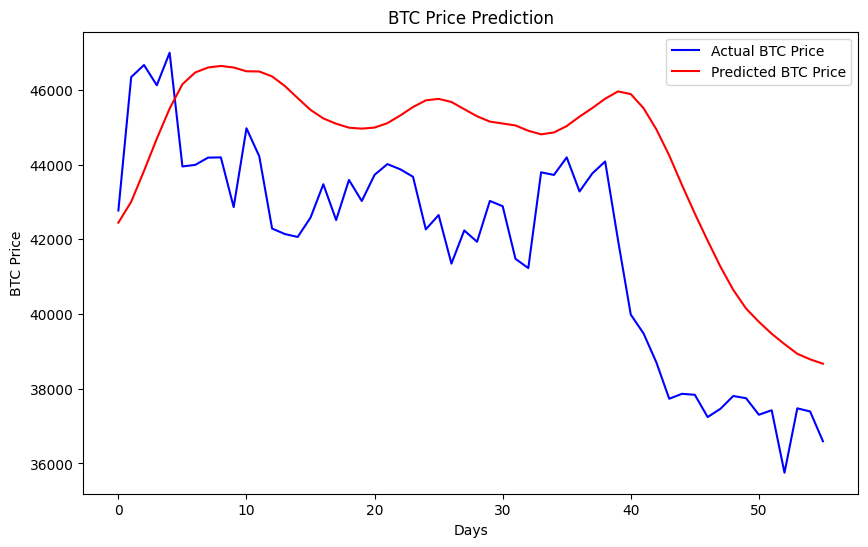

In [460]:
# Plot the results - The actual and predicted BTC prices are plotted for comparison
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(y_test_original, color='blue', label='Actual BTC Price')
plt.plot(predictions, color='red', label='Predicted BTC Price')
plt.title('BTC Price Prediction')
plt.xlabel('Days')
plt.ylabel('BTC Price')
plt.legend()
plt.show()


### Model Evaluation

In [461]:
# Evaluate the model
from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = np.sqrt(mean_squared_error(y_test_original, predictions))
mae = mean_absolute_error(y_test_original, predictions)
print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Error: {mae}")


Root Mean Squared Error: 3165.4800493738944
Mean Absolute Error: 2817.144865812352


## BACKTESTING


In [462]:
#from ibapi.client import EClient
#from ibapi.wrapper import EWrapper
#from ibapi.contract import Contract
#import time

In [463]:
#class IBApi(EWrapper, EClient):
    #def __init__(self):
        #EClient.__init__(self, self)
        #self.data = []
        #self.current_date = None

    #def nextValidId(self, orderId):
        #self.start()

    #def historicalData(self, reqId, bar):
        #self.data.append([bar.date, bar.open, bar.high, bar.low, bar.close, bar.volume])
        #self.current_date = bar.date

    #def start(self):
        #contract = Contract()
        #contract.symbol = 'BTC'
        #contract.secType = 'CRYPTO'
        #contract.exchange = 'PAXOS'
        #contract.currency = 'USD'
        #self.reqHistoricalData(1, contract, '', '1 Y', '1 day', 'MIDPOINT', 0, 1, False, [])
# Initialize IB API
#api = IBApi()
#api.connect('127.0.0.1', 7497, 0)

# Run the API to get historical data
#api.run()

In [464]:
# Backtest with real-time data
#def backtest(api, model, scaler, look_back=60):
    #while True:
      #  if api.current_date != api.data[-1][0]:
            # Fetch new data
           # new_data = np.array(api.data[-look_back:])[:, 1:].astype(float)
           # new_data_scaled = scaler.transform(new_data)

            # Prepare data for prediction
           # X_new = np.array([new_data_scaled])
           # X_new = np.reshape(X_new, (X_new.shape[0], X_new.shape[1], X_new.shape[2]))

            # Make prediction
           # prediction = model.predict(X_new)
           # prediction = scaler.inverse_transform(np.concatenate((new_data[:-1], prediction), axis=1))[:, -1][-1]

            # Print the prediction
           # print(f"Predicted Close Price: {prediction}")

            # Wait before fetching new data
           # time.sleep(86400)  # 1 day in seconds

# Start backtesting
#backtest(api, model, scaler)